# Titanic Survival Prediction — Logistic Regression

This project builds a Logistic Regression classification model to predict whether a Titanic passenger survived or did not survive.

## Dataset Overview

The Titanic dataset contains information about passengers who were onboard the Titanic.

The goal of this project is to use machine learning to predict whether a passenger survived or did not survive based on the available passenger information.

In [79]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [80]:
df = pd.read_csv("train.csv")

In [81]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Inspection

First, the dataset is loaded and inspected to understand its structure, columns, data types, and missing values.

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [83]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning

The dataset contains missing values in the Age, Cabin, and Embarked columns.

The Cabin column is dropped because it contains a large number of missing values. Missing values in the Age column are filled using the median because the median is less affected by extreme values. Missing values in the Embarked column are filled using the mode because it is a categorical feature.

In [84]:
# Drop Cabin because it has many missing values
df.drop("Cabin", axis=1, inplace=True)

# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

### Verify Missing Values

After cleaning the dataset, the missing values are checked again to confirm that the required missing values have been handled successfully.

In [85]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Feature Selection

PassengerId, Name, and Ticket are removed because they are not useful as direct predictive features for this classification model.

The remaining features provide useful information about each passenger and can be used to predict survival.

In [86]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [87]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Define Features and Target

The target variable is `Survived`, which indicates whether a passenger survived.

All remaining columns are used as input features for the machine learning model.

In [88]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

## Categorical Features

The `Sex` and `Embarked` columns contain categorical values.

Since machine learning models work with numerical data, these categorical features need to be converted into numerical representations using One-Hot Encoding.

In [89]:
categorical_features = ["Sex", "Embarked"]

## One-Hot Encoding

One-Hot Encoding is used to convert categorical values into numerical features.

The `handle_unknown="ignore"` option ensures that the model can handle categories that may appear in the test data but were not present in the training data.

In [90]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

## Logistic Regression Model

Logistic Regression is used because this is a binary classification problem.

The model predicts one of two possible outcomes:

- `0` — Did not survive
- `1` — Survived

A pipeline is used to combine the preprocessing step with the Logistic Regression model.

In [91]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

## Train-Test Split

The dataset is divided into training and testing sets using `train_test_split`.

80% of the data is used for training the model, while 20% is used for testing its performance on unseen data.

A `random_state` of 42 is used to make the split reproducible.

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

The Logistic Regression model is trained using the training features and their corresponding survival labels.

During training, the model learns patterns in the passenger data that can help predict survival.

In [93]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## Make Predictions

After training, the model is used to predict the survival outcomes of passengers in the test dataset.

In [94]:
y_pred = model.predict(X_test)

## Model Accuracy

Accuracy measures the proportion of predictions that were correctly classified out of all predictions made on the test dataset.

The Logistic Regression model achieved an accuracy of **81.01%** on the test dataset.

In [95]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", round(accuracy * 100, 2), "%")

Model Accuracy: 0.8100558659217877
Model Accuracy (%): 81.01 %


## Confusion Matrix

A confusion matrix shows the correct and incorrect predictions made by the classification model.

The rows represent the actual classes, while the columns represent the predicted classes.

- The top-left value represents passengers who did not survive and were correctly predicted as not surviving.
- The top-right value represents passengers who did not survive but were incorrectly predicted as surviving.
- The bottom-left value represents passengers who survived but were incorrectly predicted as not surviving.
- The bottom-right value represents passengers who survived and were correctly predicted as surviving.

In [96]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[90 15]
 [19 55]]


### Confusion Matrix Results

The confusion matrix produced the following results:

- **90** passengers were correctly predicted as not survived.
- **15** passengers were incorrectly predicted as survived.
- **19** passengers were incorrectly predicted as not survived.
- **55** passengers were correctly predicted as survived.

The model therefore made **145 correct predictions** out of **179 test samples**.

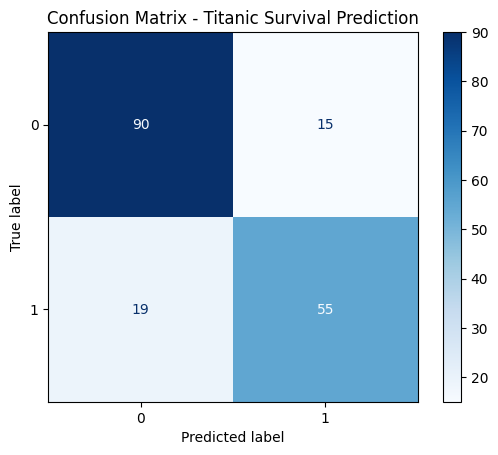

In [97]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Titanic Survival Prediction")
plt.show()

## Conclusion

In this project, a Logistic Regression classification model was developed to predict Titanic passenger survival.

The dataset was cleaned by handling missing values and removing unnecessary columns. Categorical features such as `Sex` and `Embarked` were converted into numerical features using One-Hot Encoding.

The dataset was divided into training and testing sets using an 80/20 split. The Logistic Regression model achieved an accuracy of **81.01%** on the test dataset.

The confusion matrix also helped evaluate the correct and incorrect predictions made by the model.

Overall, this project demonstrates the basic workflow of a supervised machine learning classification problem using scikit-learn.